# Grilla de ejemplos: letras (A-Z)

Muestra (y guarda) una grilla con UN ejemplo de imagen por cada letra presente en `data/asl_dataset/`, con el nombre de la clase como título de cada celda.


In [4]:
import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Ajustá esta ruta si el notebook no está en la carpeta notebooks/ de la raíz del proyecto
DATASET_DIR = Path("../data/asl_dataset")
OUTPUT_PATH = Path("../img/letters_grid.png")
COLS = 6


In [ ]:
def one_example_per_class(dataset_dir: Path, class_filter):
    """
    Recorre las subcarpetas de dataset_dir, se queda solo con las que
    cumplen class_filter(nombre_carpeta), y devuelve un dict
    {nombre_clase: ruta_a_una_imagen_de_ejemplo}.
    """
    examples = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        if not class_filter(class_dir.name):
            continue

        images = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        if images:
            examples[class_dir.name] = images[0]

    return examples


def plot_grid(examples: dict, title: str, output_path: Path, cols: int = 6, numeric_sort: bool = False):
    """
    Dibuja una grilla de imágenes, una por clase, y la guarda en
    output_path además de mostrarla.
    """
    labels = sorted(examples.keys(), key=int) if numeric_sort else sorted(examples.keys())
    n = len(labels)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, label in zip(axes, labels):
        img_bgr = cv2.imread(str(examples[label]))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(label, fontsize=14, fontweight="bold")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()

    print(f"Grilla guardada en: {output_path}")

    plt.show()


Letras encontrados: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Grilla guardada en: ..\img\letters_grid.png


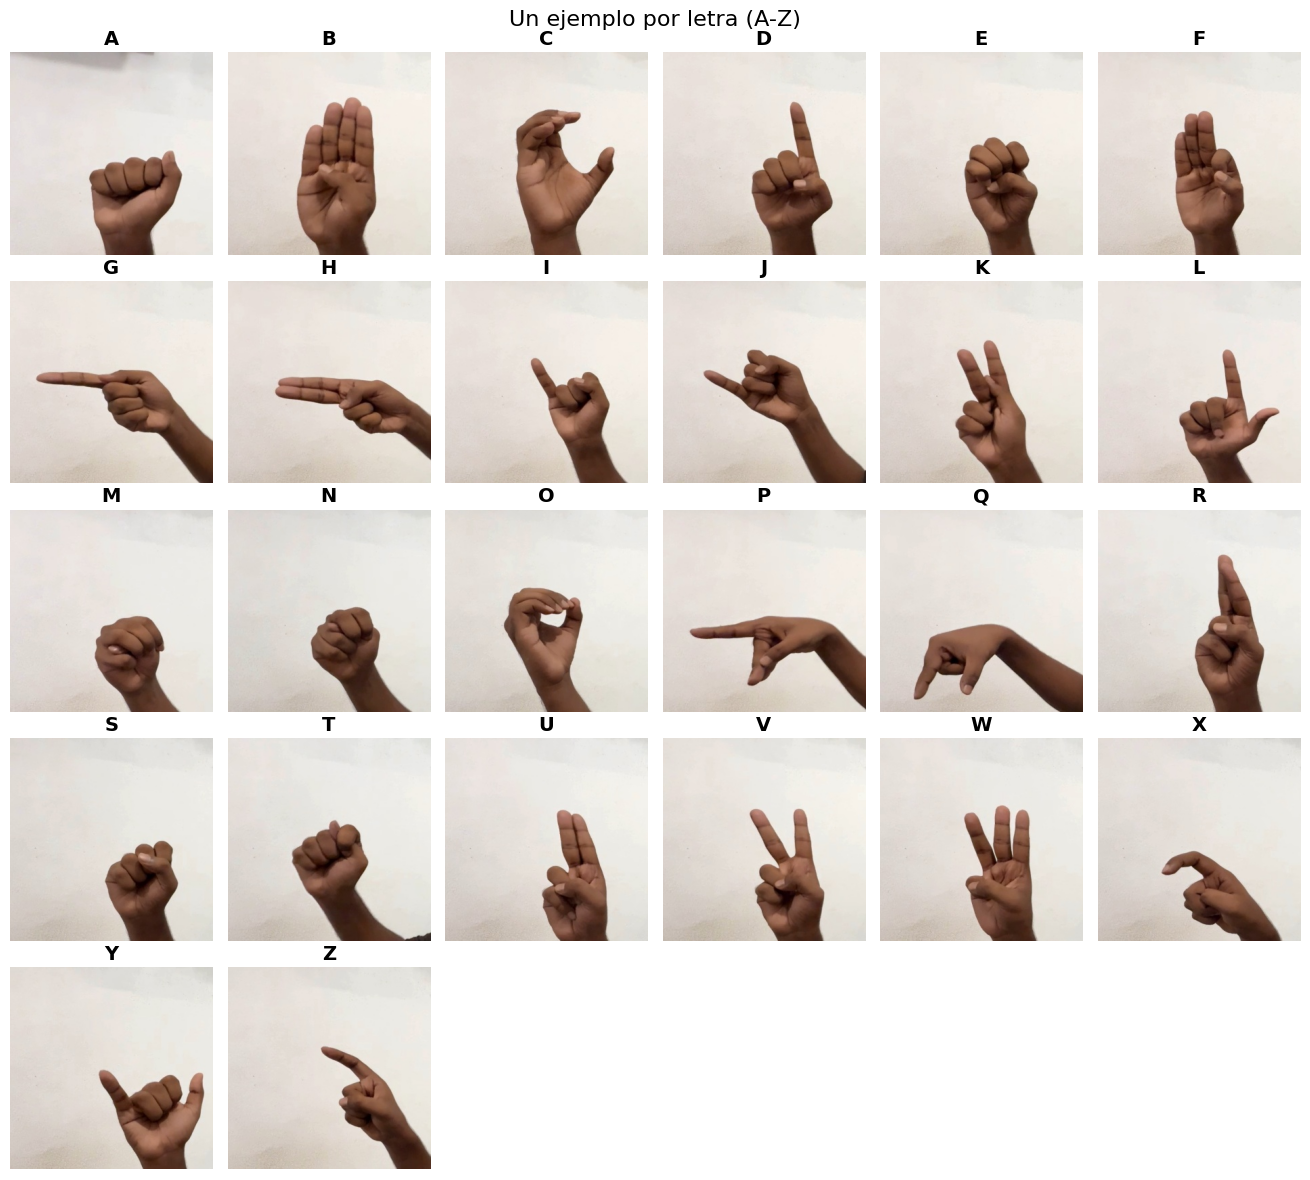

In [5]:
letter_examples = one_example_per_class(
    DATASET_DIR,
    class_filter=lambda name: len(name) == 1 and name.isalpha(),
)

print(f"Letras encontrados: {sorted(letter_examples.keys())}")

plot_grid(
    letter_examples,
    title="Un ejemplo por letra (A-Z)",
    output_path=OUTPUT_PATH,
    cols=COLS,
    numeric_sort=False,
)
